In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 1.01 s (started: 2026-06-28 22:53:41 +02:00)


In [2]:
scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets'
)

time: 17.7 s (started: 2026-06-28 22:53:42 +02:00)


In [3]:
reader = scarf.CrH5Reader('scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5')

time: 13.9 ms (started: 2026-06-28 22:53:59 +02:00)


In [4]:
reader.nCells, reader.nFeatures

(5025, 33538)

time: 999 μs (started: 2026-06-28 22:53:59 +02:00)


In [5]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    chunk_size=(2000, 1000)
)
writer.dump(batch_size=1000)

  0%|                                                                                                         …

time: 5.55 s (started: 2026-06-28 22:53:59 +02:00)


In [6]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 3.45 s (started: 2026-06-28 22:54:04 +02:00)


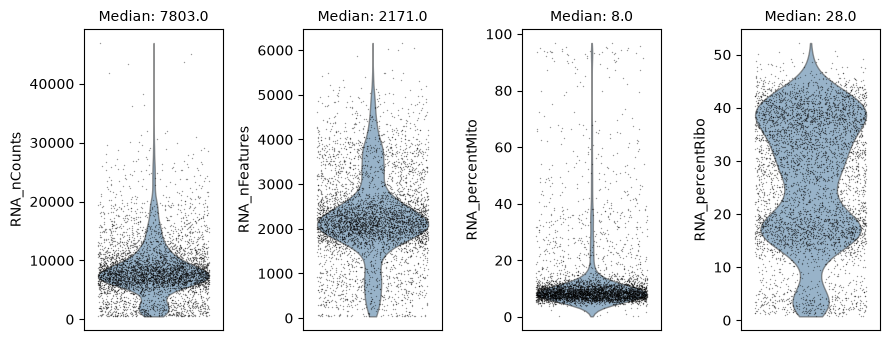

time: 961 ms (started: 2026-06-28 22:54:08 +02:00)


In [7]:
ds.plot_cells_dists()

In [8]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)

INFO: 597 cells flagged for filtering out using attribute RNA_nCounts


INFO: 461 cells flagged for filtering out using attribute RNA_nFeatures


INFO: 612 cells flagged for filtering out using attribute RNA_percentMito


time: 40.3 ms (started: 2026-06-28 22:54:09 +02:00)


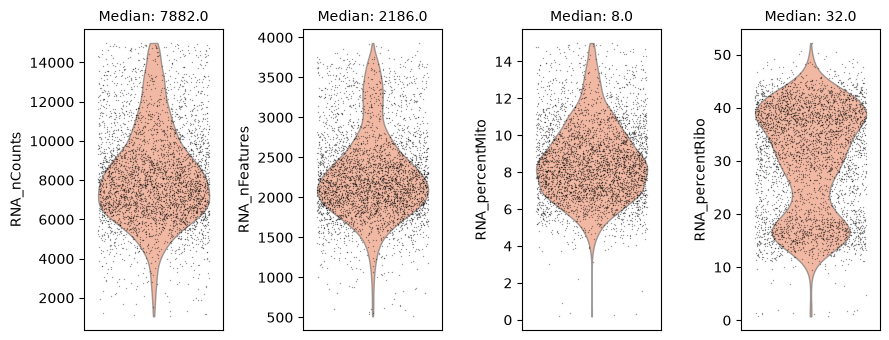

time: 560 ms (started: 2026-06-28 22:54:09 +02:00)


In [9]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_percentRibo,RNA_nFeatures,RNA_nCounts
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,16.783630,3503.0,13537.0
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,20.034733,3381.0,12668.0
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,2.494802,346.0,962.0
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,28.783690,1799.0,5788.0
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,35.750038,2887.0,13186.0


time: 65.7 ms (started: 2026-06-28 22:54:09 +02:00)


In [11]:
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_nCounts', 
            'RNA_percentRibo', 'RNA_nFeatures'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 33.3 ms (started: 2026-06-28 22:54:09 +02:00)


In [12]:
ds.RNA.feats.head()

,I,ids,names,dropOuts,nCells
0,False,ENSG00000243485,MIR1302-2HG,5025,0
1,False,ENSG00000237613,FAM138A,5025,0
2,False,ENSG00000186092,OR4F5,5025,0
3,True,ENSG00000238009,AL627309.1,4976,49
4,False,ENSG00000239945,AL627309.3,5022,3


time: 35.6 ms (started: 2026-06-28 22:54:09 +02:00)


In [13]:
ds.RNA.sf

1000

time: 1.33 ms (started: 2026-06-28 22:54:09 +02:00)


INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 498 genes marked as HVGs


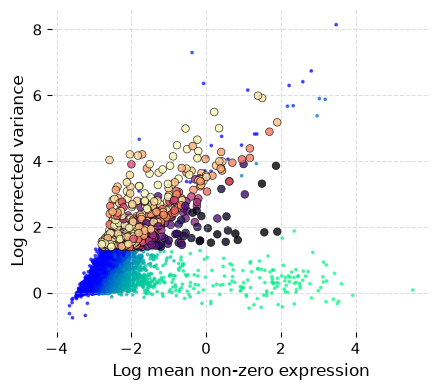

time: 5.57 s (started: 2026-06-28 22:54:09 +02:00)


In [14]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6
)

In [15]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs,stats_I_normed_tot,stats_I_nz_mean,stats_I_sigmas,stats_I_avg,stats_I_c_var__200__0.1,stats_I_normed_n
0,False,ENSG00000243485,MIR1302-2HG,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
1,False,ENSG00000237613,FAM138A,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
2,False,ENSG00000186092,OR4F5,0,5025,False,NaN,NaN,NaN,NaN,NaN,NaN
3,True,ENSG00000238009,AL627309.1,49,4976,False,4.593283,0.13919,0.000196,0.001166,1.5279,33.0
4,False,ENSG00000239945,AL627309.3,3,5022,False,NaN,NaN,NaN,NaN,NaN,NaN


time: 130 ms (started: 2026-06-28 22:54:15 +02:00)


In [16]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=15,
    n_centroids=100
)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 1.4s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.92%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 11.5s (7/7 steps, 11.4s in logged steps)


time: 11.5 s (started: 2026-06-28 22:54:15 +02:00)


In [17]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

time: 2.25 s (started: 2026-06-28 22:54:27 +02:00)


In [18]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label='dUMAP'
)

Training UMAP:   0%|                                                                                          …

time: 4.9 s (started: 2026-06-28 22:54:29 +02:00)


In [19]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_percentRibo,RNA_UMAP1,RNA_nCounts,RNA_dUMAP2,RNA_nFeatures,RNA_UMAP2,RNA_dUMAP1
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,10.844353,16.783630,5.797035,13537.0,31.469955,3503.0,33.986427,7.345896
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,5.975687,20.034733,-12.008291,12668.0,33.630154,3381.0,32.313316,-7.997371
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,53.430353,2.494802,NaN,962.0,NaN,346.0,NaN,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,10.919143,28.783690,3.294415,5788.0,15.506069,1799.0,10.993355,1.166895
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,7.955407,35.750038,-15.157138,13186.0,-8.118560,2887.0,-8.938871,-14.676094


time: 106 ms (started: 2026-06-28 22:54:33 +02:00)


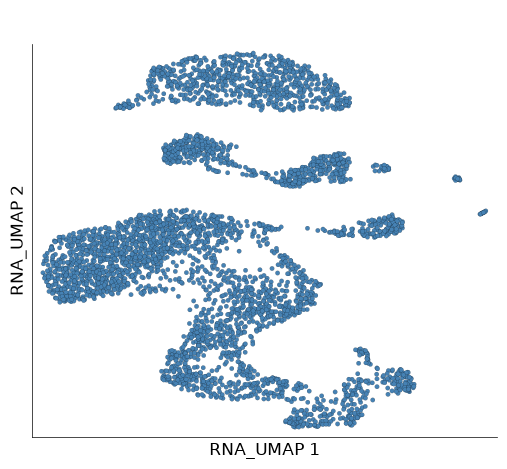

time: 124 ms (started: 2026-06-28 22:54:33 +02:00)


In [20]:
ds.plot_layout(layout_key='RNA_UMAP')

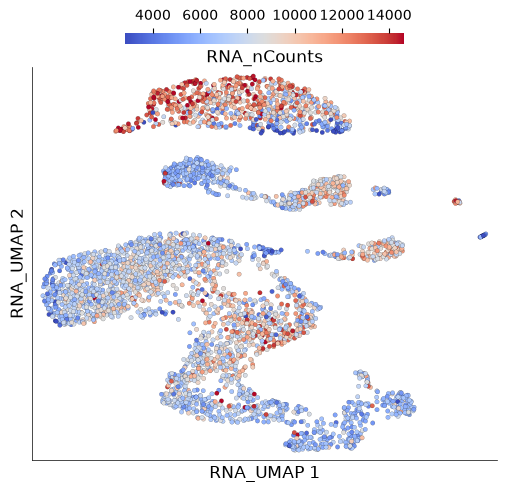

time: 234 ms (started: 2026-06-28 22:54:33 +02:00)


In [21]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm'
)

In [22]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    parallel=True
)

Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 450: error is 2.99241 (50 iterations in 0.086416 seconds)


Iteration 499: error is 2.99146 (50 iterations in 0.081534 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.135353 sec [21.6123%] |  Repulsive forces: 0.490926 sec [78.3877%]


time: 793 ms (started: 2026-06-28 22:54:34 +02:00)


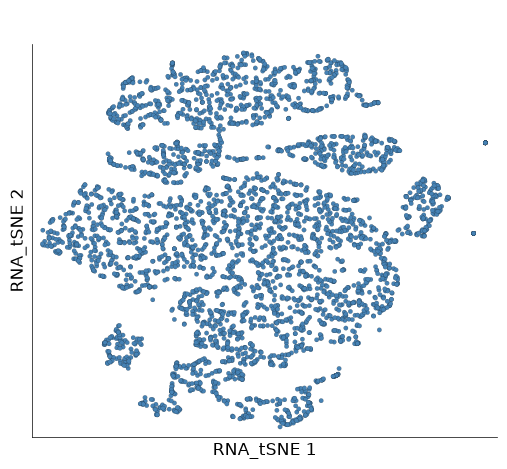

time: 111 ms (started: 2026-06-28 22:54:35 +02:00)


In [23]:
# Here we run plot_layout under exception catching because if you are not on Linux then the `run_tsne` would have failed.
try:
    ds.plot_layout(layout_key='RNA_tSNE')
except KeyError:
    print ("'RNA_tSNE1' not found in MetaData")

In [24]:
# We start with Leiden clustering
ds.run_leiden_clustering(resolution=0.5)

time: 348 ms (started: 2026-06-28 22:54:35 +02:00)


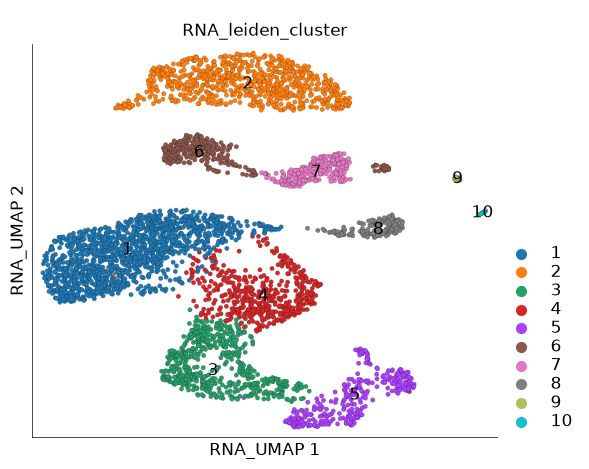

time: 258 ms (started: 2026-06-28 22:54:35 +02:00)


In [25]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster'
)

In [26]:
ds.cells.head()

,I,ids,names,RNA_tSNE1,RNA_percentMito,RNA_leiden_cluster,RNA_UMAP2,RNA_tSNE2,RNA_percentRibo,RNA_nCounts,RNA_dUMAP1,RNA_UMAP1,RNA_nFeatures,RNA_dUMAP2
0,True,AAACCCAAGCGTATGG-1,AAACCCAAGCGTATGG-1,-10.301678,10.844353,2,33.986427,19.955835,16.783630,13537.0,7.345896,5.797035,3503.0,31.469955
1,True,AAACCCAGTCCTACAA-1,AAACCCAGTCCTACAA-1,9.691213,5.975687,2,32.313316,25.038602,20.034733,12668.0,-7.997371,-12.008291,3381.0,33.630154
2,False,AAACCCATCACCTCAC-1,AAACCCATCACCTCAC-1,NaN,53.430353,-1,NaN,NaN,2.494802,962.0,NaN,NaN,346.0,NaN
3,True,AAACGCTAGGGCATGT-1,AAACGCTAGGGCATGT-1,7.522474,10.919143,7,10.993355,13.485535,28.783690,5788.0,1.166895,3.294415,1799.0,15.506069
4,True,AAACGCTGTAGGTACG-1,AAACGCTGTAGGTACG-1,-17.428382,7.955407,1,-8.938871,6.128800,35.750038,13186.0,-14.676094,-15.157138,2887.0,-8.118560


time: 166 ms (started: 2026-06-28 22:54:35 +02:00)


In [27]:
leiden_clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)
leiden_clusters.head()

,RNA_leiden_cluster
0,2
1,2
3,7
4,1
6,5


time: 48.1 ms (started: 2026-06-28 22:54:35 +02:00)


In [28]:
ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])

/tmp/ipykernel_116783/1807300542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ds.run_clustering(n_clusters=leiden_clusters.nunique()[0])


time: 313 ms (started: 2026-06-28 22:54:35 +02:00)


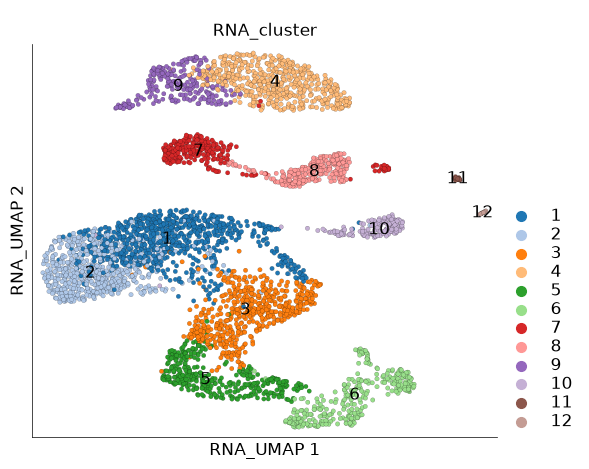

time: 283 ms (started: 2026-06-28 22:54:36 +02:00)


In [29]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster'
)

Constructing graph from dendrogram:   0%|                                                                     …

Identifying the top node for cluster:   0%|                                                                   …

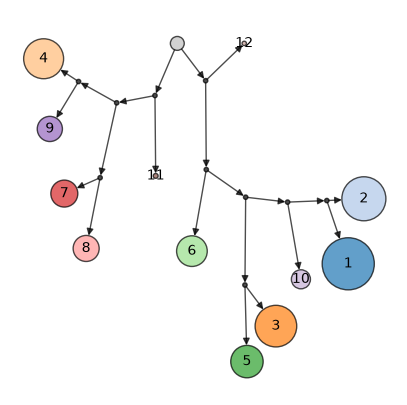

time: 380 ms (started: 2026-06-28 22:54:36 +02:00)


In [30]:
ds.plot_cluster_tree(cluster_key='RNA_cluster', width=1)

In [31]:
ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=100
)

Finding markers:   0%|                                                                                        …

time: 5.55 s (started: 2026-06-28 22:54:36 +02:00)


Aggregating marker values per group:   0%|                                                                    …

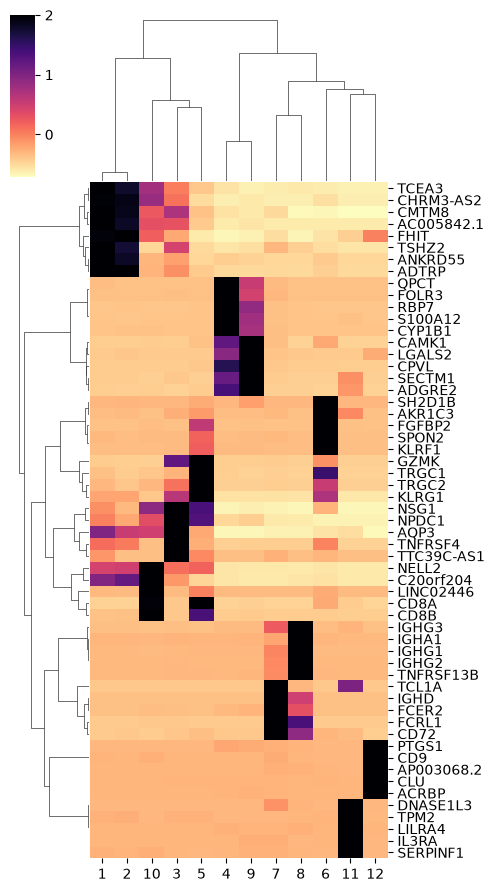

time: 1.33 s (started: 2026-06-28 22:54:42 +02:00)


In [32]:
ds.plot_marker_heatmap(
    group_key='RNA_cluster',
    topn=5,
    figsize=(5, 9)
)

In [33]:
df = ds.get_markers(
    group_key='RNA_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value
0,1,TSHZ2,29849.0,0.40857,0.08223,0.01767,0.34545,0.08738,4.65416,4.171677e-79
1,1,ANKRD55,8924.0,0.39529,0.02333,0.00401,0.15974,0.02808,5.81041,6.876416e-48
2,1,ADTRP,10307.0,0.38393,0.04075,0.00948,0.23766,0.05584,4.29811,2.141098e-55
3,1,TCEA3,487.0,0.35595,0.03329,0.00804,0.22727,0.05615,4.13832,9.997316e-51
4,1,AC005842.1,20178.0,0.34883,0.02609,0.00608,0.16494,0.04006,4.28882,4.348815e-37
...,...,...,...,...,...,...,...,...,...,...
14278,1,SYK,16290.0,0.00113,0.00054,0.06404,0.00390,0.29085,0.00838,1.921593e-62
14279,1,PDLIM1,19705.0,0.00112,0.00021,0.03954,0.00260,0.16025,0.00538,1.616561e-31
14280,1,MARCH1,8323.0,0.00110,0.00071,0.09035,0.00519,0.32240,0.00788,1.133234e-70
14281,1,ZEB2,4554.0,0.00091,0.00212,0.18227,0.01688,0.45804,0.01165,1.971131e-109


time: 154 ms (started: 2026-06-28 22:54:43 +02:00)


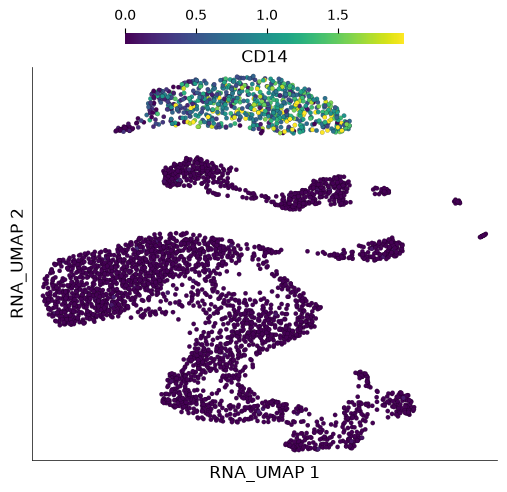

time: 302 ms (started: 2026-06-28 22:54:44 +02:00)


In [34]:
ds.plot_layout(layout_key='RNA_UMAP', color_by='CD14')